In [9]:
%matplotlib inline

%load_ext autoreload
%autoreload 2
from notebooks.imports import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
from src.utils import pmf_utils

### Load Configs

In [11]:
from config import dir_config, main_config

raw_dir = Path(dir_config.data.raw,"all_hc")
processed_dir = Path(dir_config.data.processed)

psych_model_type = 'logit_4'

## Load Data

In [12]:
aggregate_data = pd.read_csv(Path(raw_dir, "aggregate_hc_data.csv"), index_col=None)
session_metadata = pd.read_csv(Path(raw_dir, "session_metadata_detailed.csv"), encoding='latin1', index_col=None)
session_metadata.head()

,subject_id,gender,age
0,HC1,M,50
1,HC2,M,50
2,HC3,F,50
3,HC5,F,50
4,HC6,M,50


#### Fill out the subject_metadata prior based on aggregate_data

In [13]:
for subject_id in sorted(session_metadata['subject_id'], key=lambda x: int(x[2:])):
    # find the corresponding row in the aggregate data
    session_data = aggregate_data[(aggregate_data['subject_id'] == subject_id)]
    prior = np.unique(session_data['prior'])
    prior = prior[prior != 'eq']

    # in session_metadata, where subject and medication matches, update the prior
    current_idx = session_metadata[(session_metadata['subject_id'] == subject_id)].index
    session_metadata.loc[current_idx, 'prior_condition'] = prior[0]
    session_metadata.loc[current_idx, 'file_name'] = np.unique(session_data['session_filename'])[0]

In [14]:
ucla = []
case_western = []
stanford = []
harvard = ["HC1", "HC2", "HC3", "HC5", "HC6", "HC7", "HC8", "HC9", "HC12", "HC13"]

# go through the session_metadata and update the site
for subject_id in session_metadata['subject_id']:
    if subject_id in ucla:
        site = "UCLA"
    elif subject_id in case_western:
        site = "Case_Western"
    elif subject_id in stanford:
        site = "Stanford"
    elif subject_id in harvard:
        site = "Harvard"
    else:
        site = "Unknown"
    session_metadata.loc[session_metadata['subject_id'] == subject_id, "experiment_site"] = site


In [15]:
import numpy as np

print("Missing values before replacement:")
print(session_metadata.isnull().sum())

# Replace common missing value strings (case-insensitive)
missing_strings = ["", "NA", "NaN", "na", "n/a"]
for ms in missing_strings:
    session_metadata.replace(ms, np.nan, inplace=True)
    session_metadata.replace(ms.upper(), np.nan, inplace=True)
    session_metadata.replace(ms.lower(), np.nan, inplace=True)
    session_metadata.replace(ms.capitalize(), np.nan, inplace=True)

print("\nMissing values after replacement:")
print(session_metadata.isnull().sum())


Missing values before replacement:
subject_id         0
gender             0
age                0
prior_condition    0
file_name          0
experiment_site    0
dtype: int64

Missing values after replacement:
subject_id         0
gender             0
age                0
prior_condition    0
file_name          0
experiment_site    0
dtype: int64


In [16]:
print("------------- info ----------------")
print(session_metadata.info())
print("\n\n------------- head ----------------\n\n")
print(session_metadata.head())
print("\n\n------------- describe ----------------\n\n")
print(session_metadata.describe())
print("\n\n------------- dtypes ----------------\n\n")
print(session_metadata.dtypes)
print("\n\n------------- shape ----------------\n\n")
print(session_metadata.shape)

------------- info ----------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   subject_id       10 non-null     object
 1   gender           10 non-null     object
 2   age              10 non-null     int64 
 3   prior_condition  10 non-null     object
 4   file_name        10 non-null     object
 5   experiment_site  10 non-null     object
dtypes: int64(1), object(5)
memory usage: 608.0+ bytes
None


------------- head ----------------


  subject_id gender  age prior_condition file_name experiment_site
0        HC1      M   50              gr   HC1.mat         Harvard
1        HC2      M   50              rl   HC2.mat         Harvard
2        HC3      F   50              gr   HC3.mat         Harvard
3        HC5      F   50              gr   HC5.mat         Harvard
4        HC6      M   50              gl   HC6.mat         Harvard



##### Data rejection

In [17]:
valid_data = aggregate_data[aggregate_data['is_valid'] == 1]
# chose trials with minimum reaction time from main_config
valid_data = valid_data[valid_data['reaction_time'] >= main_config.BEHAVIOR.min_rt]

#### Direction and color conversion to prior condition

In [18]:
# Ensure valid_data is a DataFrame you intend to modify directly
def data_preprocessing(data):

    # remove equal prior sessions
    data = data[data['prior'] != 'eq']
    data['prior_color'].loc[data['prior'] == 'eq'] = np.nan
    data['prior_direction'].loc[data['prior'] == 'eq'] = np.nan

    left_prior_idx = data['prior_direction'] == 'left'
    right_prior_idx = data['prior_direction'] == 'right'
    green_prior_idx = data['prior_color'] == 'green'
    red_prior_idx = data['prior_color'] == 'red'

    # Renaming directions based on prior direction
    data.loc[left_prior_idx, 'target'] = data.loc[left_prior_idx, 'target'].map({'left': 1, 'right': 0})
    data.loc[left_prior_idx, 'choice'] = data.loc[left_prior_idx, 'choice'].map({'left': 1, 'right': 0})
    data.loc[right_prior_idx, 'target'] = data.loc[right_prior_idx, 'target'].map({'left': 0, 'right': 1})
    data.loc[right_prior_idx, 'choice'] = data.loc[right_prior_idx, 'choice'].map({'left': 0, 'right': 1})

    # Renaming colors based on prior color
    data.loc[green_prior_idx, 'color'] = data.loc[green_prior_idx, 'color'].map({'green': 1, 'red': 0})
    data.loc[red_prior_idx, 'color'] = data.loc[red_prior_idx, 'color'].map({'green': 0, 'red': 1})

    data['signed_coherence'] = data['coherence'] * (2 * data['target'] - 1)

    return data

valid_data = data_preprocessing(valid_data)
aggregate_data = data_preprocessing(aggregate_data)

#### Data Splicing

In [19]:
slicing = main_config.BEHAVIOR.data_slice

temp_valid_data = pd.DataFrame()
temp_aggregate_data = pd.DataFrame()

if slicing != 0:
	for subject_id in sorted(list(aggregate_data.subject_id.unique()), key=lambda x: int(x[2:])):
		# find the corresponding row in the aggregate data
		session_agg_data = aggregate_data[(aggregate_data['subject_id'] == subject_id)]
		session_valid_data = valid_data[(valid_data['subject_id'] == subject_id)]

		if session_agg_data.empty or session_valid_data.empty:
			continue

		half = len(session_agg_data) // 2

		if slicing == 1:
			# Take first half
			agg_slice = session_agg_data.iloc[:half]
			valid_slice = session_valid_data.iloc[:half]
		elif slicing == 2:
			# Take second half
			agg_slice = session_agg_data.iloc[half:]
			valid_slice = session_valid_data.iloc[half:]
		else:
			# Use full session if slicing value is unexpected
			agg_slice = session_agg_data
			valid_slice = session_valid_data

		# Concatenate results
		temp_aggregate_data = pd.concat([temp_aggregate_data, agg_slice], ignore_index=True)
		temp_valid_data = pd.concat([temp_valid_data, valid_slice], ignore_index=True)

	aggregate_data = temp_aggregate_data
	valid_data = temp_valid_data

#### Rejecting sessions based on allowed lapse rates

In [20]:
sessions = valid_data['session_filename'].unique()

reject_sessions = []

for session in sessions:
	session_data = valid_data[valid_data['session_filename'] == session]
	accuracy_100prct = np.mean(session_data['outcome'][np.abs(session_data['coherence']) == 100]) * 100
	if accuracy_100prct < main_config.BEHAVIOR.min_easy_accuracy * 100:
		reject_sessions.append(session)
		print(f"Subject: {session} rejected due to low accuracy {accuracy_100prct:.2f}, with session size {len(session_data)}")
		continue

aggregate_data = aggregate_data[~aggregate_data['session_filename'].isin(reject_sessions)]
valid_data = valid_data[~valid_data['session_filename'].isin(reject_sessions)]


Subject: HC5.mat rejected due to low accuracy 58.28, with session size 610
Subject: HC2.mat rejected due to low accuracy 46.54, with session size 634


In [21]:
valid_subjects = valid_data.subject_id.unique()
valid_subjects


array(['HC8', 'HC1', 'HC6', 'HC7', 'HC9', 'HC3', 'HC12', 'HC13'],
      dtype=object)

In [22]:

aggregate_data = aggregate_data[aggregate_data['subject_id'].isin(valid_subjects)]
valid_data = valid_data[valid_data['subject_id'].isin(valid_subjects)]
valid_session_metadata = session_metadata[session_metadata['subject_id'].isin(valid_subjects)]

print(f"Number of valid subjects: {len(valid_subjects)}")
print(valid_subjects)
print(f"Number of subjects: {len(valid_data['subject_id'].unique())}")
print(valid_data['subject_id'].unique())
print(f"Number of sessions: {len(valid_session_metadata['subject_id'].unique())}")
print(valid_session_metadata['subject_id'].unique())


Number of valid subjects: 8
['HC8' 'HC1' 'HC6' 'HC7' 'HC9' 'HC3' 'HC12' 'HC13']
Number of subjects: 8
['HC8' 'HC1' 'HC6' 'HC7' 'HC9' 'HC3' 'HC12' 'HC13']
Number of sessions: 8
['HC1' 'HC3' 'HC6' 'HC7' 'HC8' 'HC9' 'HC12' 'HC13']


In [23]:
# adding session_id to each subject off and on medication sessions

session_metadata['positive_bias'] = np.nan
session_metadata['positive_bias'] = np.nan
session_metadata['positive_psych_alpha'] = np.nan
session_metadata['positive_psych_beta'] = np.nan
session_metadata['positive_psych_lapse'] = np.nan
session_metadata['positive_psych_guess'] = np.nan

session_metadata['equal_psych_bias'] = np.nan
session_metadata['equal_psych_bias'] = np.nan
session_metadata['equal_psych_alpha'] = np.nan
session_metadata['equal_psych_beta'] = np.nan
session_metadata['equal_psych_lapse'] = np.nan
session_metadata['equal_psych_guess'] = np.nan

for subject in valid_subjects:
    session_data = valid_data[(valid_data['subject_id'] == subject)]

    current_idx = session_metadata[(session_metadata['subject_id'] == subject)].index

    positive_bias, positive_psych_bias, positive_psych_alpha, positive_psych_beta, positive_psych_lapse, positive_psych_guess = np.nan, np.nan, np.nan, np.nan, np.nan, np.nan
    equal_bias, equal_psych_bias, equal_psych_alpha, equal_psych_beta, equal_psych_lapse, equal_psych_guess = np.nan, np.nan, np.nan, np.nan, np.nan, np.nan

    coh, positive_psych, positive_model, _, _, = pmf_utils.get_psychometric_data(data=session_data[session_data['color'] == 1], model_type=psych_model_type)
    coh, equal_psych, equal_model, _, _, = pmf_utils.get_psychometric_data(data=session_data[session_data['color'] == 0], model_type=psych_model_type)

    session_metadata.loc[current_idx, 'positive_bias'] = positive_psych[3]
    session_metadata.loc[current_idx, 'positive_psych_bias'] = positive_model.predict(0)
    session_metadata.loc[current_idx, 'positive_psych_alpha'] = positive_model.coefs_['mean']
    session_metadata.loc[current_idx, 'positive_psych_beta'] = positive_model.coefs_['var']
    session_metadata.loc[current_idx, 'positive_psych_lapse'] = positive_model.coefs_['lapse_rate']
    session_metadata.loc[current_idx, 'positive_psych_guess'] = positive_model.coefs_['guess_rate']

    session_metadata.loc[current_idx, 'equal_bias'] = equal_psych[3]
    session_metadata.loc[current_idx, 'equal_psych_bias'] = equal_model.predict(0)
    session_metadata.loc[current_idx, 'equal_psych_alpha'] = equal_model.coefs_['mean']
    session_metadata.loc[current_idx, 'equal_psych_beta'] = equal_model.coefs_['var']
    session_metadata.loc[current_idx, 'equal_psych_lapse'] = equal_model.coefs_['lapse_rate']
    session_metadata.loc[current_idx, 'equal_psych_guess'] = equal_model.coefs_['guess_rate']


### Input decision-behavior parameters into session_metadata

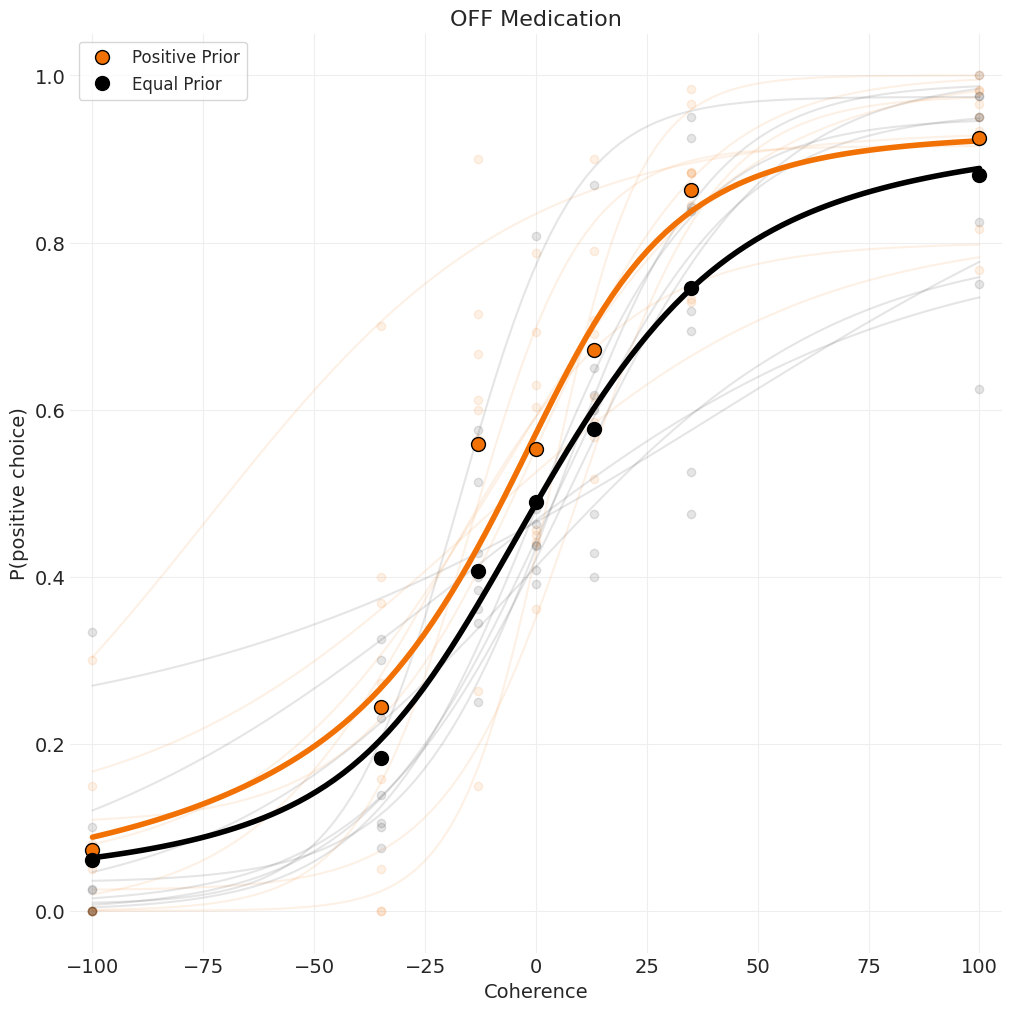

In [ ]:
# for each subject, plot psychometric function for on and off medication sessions for positive and negative colors

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
subject_alpha = 0.1
positive_color = 'C5'
equal_color = 'black'

sub_off_pos_coh, sub_off_pos_psych, sub_off_pos_model, sub_off_pos_x_hat, sub_off_pos_y_hat = [], [], [], [], []
sub_off_eq_coh, sub_off_eq_psych, sub_off_eq_model, sub_off_eq_x_hat, sub_off_eq_y_hat = [], [], [], [], []
sub_on_pos_coh, sub_on_pos_psych, sub_on_pos_model, sub_on_pos_x_hat, sub_on_pos_y_hat = [], [], [], [], []
sub_on_eq_coh, sub_on_eq_psych, sub_on_eq_model, sub_on_eq_x_hat, sub_on_eq_y_hat = [], [], [], [], []


for i, subject in enumerate(valid_subjects):
    subject_data = valid_data[valid_data["subject_id"] == subject]

    subject_metadata = session_metadata.loc[session_metadata["subject_id"] == subject]
    pos_coh, pos_psych, pos_model, pos_x_hat, pos_y_hat = pmf_utils.get_psychometric_data(subject_data[subject_data["color"] == 1], model_type=psych_model_type)
    eq_coh, eq_psych, eq_model, eq_x_hat, eq_y_hat = pmf_utils.get_psychometric_data(subject_data[subject_data["color"] == 0], model_type=psych_model_type)

    ax_idx = 0
    sub_off_pos_coh.append(pos_coh)
    sub_off_pos_psych.append(pos_psych)
    sub_off_pos_model.append(pos_model)
    sub_off_pos_x_hat.append(pos_x_hat)
    sub_off_pos_y_hat.append(pos_y_hat)
    sub_off_eq_coh.append(eq_coh)
    sub_off_eq_psych.append(eq_psych)
    sub_off_eq_model.append(eq_model)
    sub_off_eq_x_hat.append(eq_x_hat)
    sub_off_eq_y_hat.append(eq_y_hat)

    ax.plot(pos_coh, pos_psych, color=positive_color, marker="o", linestyle="", alpha=subject_alpha)
    ax.plot(pos_x_hat, pos_y_hat, color=positive_color, linestyle="-", alpha=subject_alpha)
    ax.plot(eq_coh, eq_psych, color=equal_color, marker="o", linestyle="", alpha=subject_alpha)
    ax.plot(eq_x_hat, eq_y_hat, color=equal_color, linestyle="-", alpha=subject_alpha)

ax.plot(np.mean(sub_off_pos_x_hat, axis=0), np.mean(sub_off_pos_y_hat, axis=0), color=positive_color, linestyle='-',  lw=4, alpha=1)
ax.plot(np.mean(sub_off_eq_x_hat, axis=0), np.mean(sub_off_eq_y_hat, axis=0), color=equal_color, linestyle='-',  lw=4, alpha=1)
ax.plot(np.mean(sub_off_pos_coh, axis=0), np.mean(sub_off_pos_psych, axis=0), color=positive_color, marker='o', linestyle='', ms=10, mec='k', label='Positive Prior', alpha=1)
ax.plot(np.mean(sub_off_eq_coh, axis=0), np.mean(sub_off_eq_psych, axis=0), color=equal_color, marker='o', linestyle='', ms=10, mec='k', label='Equal Prior', alpha=1)

ax.set_title(f"OFF Medication", fontsize=16)
ax.set_xlabel('Coherence', fontsize=14)
ax.set_ylabel('P(positive choice)', fontsize=14)
ax.set_xlim(-105, 105)
ax.set_ylim(-0.05, 1.05)
ax.legend()


In [18]:
# for each subject, plot psychometric function for on and off medication sessions for positive and negative colors

subject_alpha = 0.08
positive_color = 'C5'
equal_color = 'black'
error_plot_style = {'elinewidth': 2, 'capsize': 10, 'capthick': 2}

ax[idx].plot(pos_coh, pos_psych, color=positive_color, ls='', alpha=subject_alpha)
ax[idx].plot(pos_x_hat, pos_y_hat, color=positive_color, ls='-', alpha=subject_alpha)
ax[idx].plot(eq_coh, eq_psych, color=equal_color, ls='', alpha=subject_alpha)
ax[idx].plot(eq_x_hat, eq_y_hat, color=equal_color, ls='-', alpha=subject_alpha)

for i, subject in enumerate(valid_subjects):
    continue

    fig, ax = plt.subplots(1, 2, figsize=(10, 5))

    subject_data = valid_data[valid_data['subject_id'] == subject]
    subject_data = subject_data.sort_values('medication')

    for idx, med in enumerate(subject_data['medication'].unique()):
        med_data = subject_data[subject_data['medication'] == med]
        coh, psych, model, x_hat, y_hat = pmf_utils.get_psychometric_data(med_data[med_data['color'] == 1], model_type='logit_4')
        ax[idx].plot(coh, psych, marker='o', ms=12, mec='k', color=positive_color, ls='', label='Positive Prior')
        ax[idx].plot(x_hat, y_hat, color=positive_color, ls='-')
        coh, psych, model, x_hat, y_hat = pmf_utils.get_psychometric_data(med_data[med_data['color'] == 0], model_type='logit_4')
        ax[idx].plot(coh, psych, marker='o', ms=12, mec='k', color=equal_color, ls='', label='Equal Prior')
        ax[idx].plot(x_hat, y_hat, color=equal_color, ls='-')
        ax[idx].set_title(f"Medication: {med}", fontsize=16)
        ax[idx].set_xlabel('Coherence', fontsize=14)
        ax[idx].set_ylabel('P(positive choice)', fontsize=14)
        ax[idx].legend()
        ax[idx].set_ylim(-0.05, 1.05)
        ax[idx].tick_params(axis='both', labelsize=14)
        ax[idx].spines['top'].set_visible(False)
        ax[idx].spines['right'].set_visible(False)

    fig.suptitle(f"Subject: {subject}", fontsize=20)

### Save data and data results (metadata)

In [32]:
session_metadata.keys()

Index(['subject_id', 'gender', 'age', 'prior_condition', 'file_name',
       'experiment_site', 'positive_bias', 'positive_psych_alpha',
       'positive_psych_beta', 'positive_psych_lapse', 'positive_psych_guess',
       'equal_psych_bias', 'equal_psych_alpha', 'equal_psych_beta',
       'equal_psych_lapse', 'equal_psych_guess', 'positive_psych_bias',
       'equal_bias'],
      dtype='object')

In [33]:
session_metadata = session_metadata[session_metadata['subject_id'].isin(valid_subjects)]
valid_data = valid_data[valid_data['subject_id'].isin(valid_subjects)]
aggregate_data = aggregate_data[aggregate_data['subject_id'].isin(valid_subjects)]

session_metadata.to_csv(Path(processed_dir, "processed_hc_metadata_accu_60.csv"), index=False)
aggregate_data.to_csv(Path(processed_dir, "processed_hc_data_accu_60_all.csv"), index=False)
valid_data.to_csv(Path(processed_dir, "processed_hc_data_accu_60_filtered.csv"), index=False)